In [1]:
import pandas as pd
import os

In [2]:
SESSION_FILES = [
    "meetinglistdetails_2026_05_29_2026_05_29.csv",
    "meetinglistdetails_2026_05_30_2026_05_30.csv",
]
INTERNSHIP_KEYWORD = "Machine Learning"
CERTIFICATION_THRESHOLD = 0.80
MIN_ATTENDANCE_PERCENT = 0.50

In [3]:
all_sessions = []
for file in SESSION_FILES:
    df = pd.read_csv(file)
    df = df[df["Topic"].str.contains(INTERNSHIP_KEYWORD, na=False)].copy()
    print(f"Loaded: {file} → {len(df)} rows")
    all_sessions.append(df)

raw = pd.concat(all_sessions, ignore_index=True)
print(f"\nTotal rows: {len(raw)}")

Loaded: meetinglistdetails_2026_05_29_2026_05_29.csv → 1814 rows
Loaded: meetinglistdetails_2026_05_30_2026_05_30.csv → 2162 rows

Total rows: 3976


In [4]:
raw["session_duration_min"] = raw["Duration (minutes)"]
raw["student_duration_min"] = raw["Duration (minutes).1"]
raw["session_date"] = pd.to_datetime(raw["Start time"], dayfirst=False).dt.date
raw["is_present"] = raw["student_duration_min"] >= (raw["session_duration_min"] * MIN_ATTENDANCE_PERCENT)
print("Present/Absent marked!")

Present/Absent marked!


C:\Users\Abzal\AppData\Local\Temp\ipykernel_13588\3598812673.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  raw["session_date"] = pd.to_datetime(raw["Start time"], dayfirst=False).dt.date


In [5]:
session_level = (
    raw.groupby(["Email", "session_date"])
    .agg(student_name=("Name (original name)", "first"),
         present=("is_present", "any"))
    .reset_index()
)
total_sessions = session_level["session_date"].nunique()
print(f"Total sessions: {total_sessions}")
print(f"Total students: {session_level['Email'].nunique()}")

Total sessions: 2
Total students: 869


In [6]:
student_summary = (
    session_level.groupby(["Email", "student_name"])
    .agg(sessions_attended=("present", "sum"),
         total_sessions=("present", "count"))
    .reset_index()
)
student_summary["attendance_%"] = ((student_summary["sessions_attended"] / total_sessions) * 100).round(2)
student_summary["status"] = student_summary["attendance_%"].apply(
    lambda x: "CERTIFIED" if x >= CERTIFICATION_THRESHOLD * 100 else "NOT CERTIFIED"
)
student_summary = student_summary.sort_values("attendance_%", ascending=False).reset_index(drop=True)
print("Done!")

Done!


In [7]:
certified = student_summary[student_summary["status"] == "CERTIFIED"]
not_certified = student_summary[student_summary["status"] == "NOT CERTIFIED"]

print("=" * 40)
print(f"  Total Students  : {len(student_summary)}")
print(f"  CERTIFIED       : {len(certified)}")
print(f"  NOT CERTIFIED   : {len(not_certified)}")
print("=" * 40)

print("\n✅ CERTIFIED STUDENTS:")
display(certified[["student_name", "Email", "attendance_%"]].reset_index(drop=True))

print("\n❌ NOT CERTIFIED STUDENTS:")
display(not_certified[["student_name", "Email", "attendance_%"]].reset_index(drop=True))

  Total Students  : 1086
  CERTIFIED       : 192
  NOT CERTIFIED   : 894

✅ CERTIFIED STUDENTS:


,student_name,Email,attendance_%
0,Y Venky,yvenky080@gmail.com,100.0
1,Younis Doraboina_23001A0544_JNTUACEA ( Younis ...,younisdoraboina@gmail.com,100.0
2,Harshika Bokka,23221a4207@bvcgroup.in,100.0
3,tupakula bala yesu,yesubala40@gmail.com,100.0
4,B Vijay-234M1A2505 Vemu Institute Of Technology,viji24980@gmail.com,100.0
...,...,...,...
187,Yagnesh Naidu,yagneshnaidu410@gmail.com,100.0
188,Jagannadham Sudharani,23bq1a4264@vvit.net,100.0
189,Cherukuri Supriya Sundari-23BQ1A4229-VVIT ( Ch...,23bq1a4229@vvit.net,100.0
190,Vydani Navya Sree_23221A4250_BVCEC(odalarevu) ...,23221a4250@bvcgroup.in,100.0



❌ NOT CERTIFIED STUDENTS:


,student_name,Email,attendance_%
0,23221a4231@bvcgroup.in,23221a4231@bvcgroup.in,50.0
1,V Yoga sree-234M1A05I3-Vemu Institute Of Techn...,yogasree28005@gmail.com,50.0
2,23221A4241_Pilli Renuka_BVCEC ( Renuka Pilli ),23221a4241@bvcgroup.in,50.0
3,Jaswant reddy A24126552066 Anits,yerusujaswanthreddy@gmail.com,50.0
4,Beemanadham Purna chandu naga sai lakshman-232...,23221a6105@bvcgroup.in,50.0
...,...,...,...
889,Yamini Reddy,yaminireddylingala120507@gmail.com,0.0
890,244M5A2501 A VISHNUVARDHAN VEMU IT ( VISHNU VA...,vv8125218517@gmail.com,0.0
891,lakshmi tejaswini V 23BQ1A42I4 VVIT,vuddantilakshmitejaswini@gmail.com,0.0
892,23BQ1A4245-GADAMSETTY G L NARASIMHA HANUMA SAK...,23bq1a4245@vvit.net,0.0


In [8]:
with pd.ExcelWriter("Certification_Results.xlsx", engine="openpyxl") as writer:
    certified.to_excel(writer, sheet_name="Certified", index=False)
    not_certified.to_excel(writer, sheet_name="Not Certified", index=False)

print("✅ Excel file saved: Certification_Results.xlsx")

✅ Excel file saved: Certification_Results.xlsx


In [9]:
print("="*60)
print("        ML INTERNSHIP ATTENDANCE REPORT")
print("="*60)

print(f"Total Students           : {len(student_summary)}")
print(f"Sessions Loaded          : {total_sessions}")
print(f"Attendance Threshold     : {CERTIFICATION_THRESHOLD*100}%")
print(f"Certified Students       : {len(certified)}")
print(f"Not Certified Students   : {len(not_certified)}")

print("="*60)

        ML INTERNSHIP ATTENDANCE REPORT
Total Students           : 1086
Sessions Loaded          : 2
Attendance Threshold     : 80.0%
Certified Students       : 192
Not Certified Students   : 894


In [10]:
from IPython.display import display

print("\n" + "="*70)
print("               CERTIFIED STUDENTS")
print("="*70)

certified_display = certified[
    [
        "student_name",
        "Email",
        "sessions_attended",
        "attendance_%"
    ]
].copy()

certified_display.columns = [
    "Student Name",
    "Email",
    "Sessions Attended",
    "Attendance %"
]

display(certified_display.sort_values(by="Attendance %", ascending=False))


               CERTIFIED STUDENTS


,Student Name,Email,Sessions Attended,Attendance %
0,Y Venky,yvenky080@gmail.com,2,100.0
1,Younis Doraboina_23001A0544_JNTUACEA ( Younis ...,younisdoraboina@gmail.com,2,100.0
2,Harshika Bokka,23221a4207@bvcgroup.in,2,100.0
3,tupakula bala yesu,yesubala40@gmail.com,2,100.0
4,B Vijay-234M1A2505 Vemu Institute Of Technology,viji24980@gmail.com,2,100.0
...,...,...,...,...
187,Yagnesh Naidu,yagneshnaidu410@gmail.com,2,100.0
188,Jagannadham Sudharani,23bq1a4264@vvit.net,2,100.0
189,Cherukuri Supriya Sundari-23BQ1A4229-VVIT ( Ch...,23bq1a4229@vvit.net,2,100.0
190,Vydani Navya Sree_23221A4250_BVCEC(odalarevu) ...,23221a4250@bvcgroup.in,2,100.0


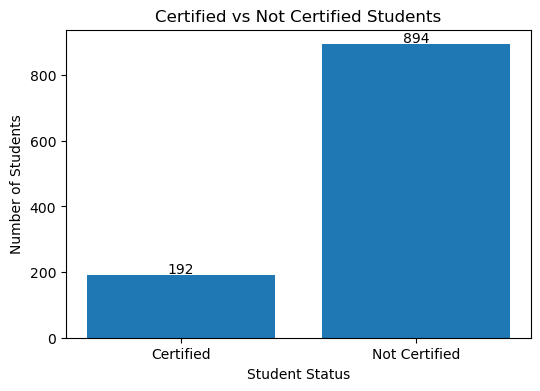

In [11]:
import matplotlib.pyplot as plt

# Data for graph
labels = ["Certified", "Not Certified"]
counts = [len(certified), len(not_certified)]

# Create bar chart
plt.figure(figsize=(6,4))
plt.bar(labels, counts)

plt.title("Certified vs Not Certified Students")
plt.xlabel("Student Status")
plt.ylabel("Number of Students")

# Show values on top of bars
for i, count in enumerate(counts):
    plt.text(i, count + 5, str(count), ha='center')

plt.show()

In [13]:
with pd.ExcelWriter("Certification_Results.xlsx", engine="openpyxl") as writer:
    certified.to_excel(writer, sheet_name="Certified", index=False)
    not_certified.to_excel(writer, sheet_name="Not Certified", index=False)

print("✅ Excel file saved: Certification_Results.xlsx")

✅ Excel file saved: Certification_Results.xlsx
